In [7]:
import os
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display
from pathlib import Path
import sys
import cv2
import random
import numpy as np

PROJECT_ROOT = Path.cwd().parent 
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
from multi_char_classifier.utils import load_config

config = load_config("config.yaml")


augmentations = {
    "do_rotation": True,
    "do_blur": True,
    "do_brightness_contrast": True,
    "do_jitter": True
}


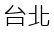

In [8]:

def create_image(
    phrase,
    do_rotation=False,
    do_blur=False,
    do_brightness_contrast=False,
    do_jitter=False,
):
    img_width = len(phrase) * 27
    img = Image.new("L", (img_width, 32), color=255)
    draw = ImageDraw.Draw(img)

    font_path = "C:/Windows/Fonts/msjh.ttc"
    try:
        font = ImageFont.truetype(font_path, 24)
    except IOError:
        font = ImageFont.load_default()

    # Draw text
    bbox = draw.textbbox((0, 0), phrase, font=font)
    text_w, text_h = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x = (img.width - text_w) // 2 - bbox[0]
    y = (img.height - text_h) // 2 - bbox[1]
    draw.text((x, y), phrase, font=font, fill=0)


    # --- Data augmentations --- #
    # 1. Text rotation
    if do_rotation and random.random() < 0.5:
        rot_level = random.uniform(-3, 3)
        img = img.rotate(rot_level, resample=Image.BICUBIC, expand=False, fillcolor=255)
    
    img_np = np.array(img)

    # 2. Text jitter
    if do_jitter and random.random() < 0.5:
        tx = random.randint(-2, 2)
        ty = random.randint(-2, 2)
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        img_np = cv2.warpAffine(
            img_np, M, (img_np.shape[1], img_np.shape[0]),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=255
        )
    
    # 3. Gaussian blur
    if do_blur and random.random() < 0.5:
        noise_level = random.uniform(0, 1)
        img_np = cv2.GaussianBlur(img_np, (0, 0), sigmaX=noise_level, sigmaY=noise_level)

    if do_brightness_contrast  and random.random() < 0.5:
        alpha = random.uniform(0.85, 1.15)  # contrast
        beta = random.uniform(-20, 20)      # brightness
        img_np = np.clip(alpha * img_np + beta, 0, 255).astype(np.uint8)
    
    img = Image.fromarray(img_np)
    return img


phrases = ["台北", "台灣大學", "營業時間", "捷運站", "台北捷運"]
phrase = random.choice(phrases)
img = create_image(phrase, do_rotation=True, do_blur=False, do_brightness_contrast=True, do_jitter=True)
display(img)

In [13]:
def create_dummy_dataset(vocab, phrases, dataset_dir):
    # 1. Setup directories
    os.makedirs(dataset_dir / config['paths']['train_img_dir'], exist_ok=True)
    os.makedirs(dataset_dir / config['paths']['val_img_dir'], exist_ok=True)
    
    # 2. Check if Phrases contain chars not in vocab
    for phrase in phrases:
        for char in phrase:
            if char not in vocab:
                print()
                print("Phrase:", phrase, "Faulty char:", char)
                raise Exception("Error: Phrase contains char that isn't in the vocabulary\n", "Phrase:", phrase, "Faulty char:", char)

    # 3. Save vocab.txt
    with open(dataset_dir / config['paths']['vocab_path'], "w", encoding="utf-8") as f:
        f.write("\n".join(vocab))

    
    # 4. Create train dataset (with augmentations)
    train_samples = phrases * 1000
    random.shuffle(train_samples)
    train_labels = []
    
    for i, phrase in enumerate(train_samples):
        img = create_image(phrase, **augmentations)
        filename = f"image_train_{i:03d}.png"
        train_labels.append({"filename": filename, "text": phrase})
        img.save(dataset_dir / config['paths']['train_img_dir'] / filename)

    df = pd.DataFrame(train_labels)
    df.to_csv(dataset_dir / config['paths']['train_labels_csv'], index=False)

    #. 5. Create val dataset (no augmentations)
    train_samples = phrases
    random.shuffle(train_samples)
    train_labels = []
    
    for i, phrase in enumerate(train_samples):
        img = create_image(phrase, 
                           do_rotation=False, 
                           do_blur=False, 
                           do_brightness_contrast=False, 
                           do_jitter=False
        )
        filename = f"image_val_{i:03d}.png"
        train_labels.append({"filename": filename, "text": phrase})
        img.save(dataset_dir / config['paths']['val_img_dir'] / filename)

    df = pd.DataFrame(train_labels)
    df.to_csv(dataset_dir / config['paths']['val_labels_csv'], index=False)

   
    print("Dummy dataset created successfully!")

In [5]:
# Create a dummy dataset for Mandaring OCR using 5 phrases
vocab = ["台", "北", "灣", "營", "業", "時", "間", "捷", "運", "站", "大", "學"]
phrases = ["台北", "台灣大學", "營業時間", "捷運站", "台北捷運"]
dataset_dir = PROJECT_ROOT / config['paths']['dataset5']
print(dataset_dir)
create_dummy_dataset(vocab, phrases, dataset_dir)

c:\Dev\hanzi_classifier\classifier\data\dummy_OCR5
Dummy dataset created successfully!


In [15]:
# Create a dummy dataset for Mandaring OCR using 10 phrases
vocab = ["台", "北", "灣", "營", "業", "時", "間", "捷", "運", "站", "大", "學"]
phrases = ["台北", "時間", "台灣", "台北站", "台灣大學", "營業時間", "捷運站", "台北捷運", "台灣時間", "台北捷運站"]
dataset_dir = PROJECT_ROOT / config['paths']['dataset10']
print(dataset_dir)
create_dummy_dataset(vocab, phrases, dataset_dir)

c:\Dev\hanzi_classifier\classifier\data\dummy_OCR10
Dummy dataset created successfully!
